<a href="https://colab.research.google.com/github/Somrat390/Pytorch/blob/main/Neural_Network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import torch
from torch import nn
torch.__version__

'2.11.0+cu128'

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [35]:
import sklearn

In [36]:
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples, noise=0.3, random_state=42)

In [37]:
len(X), len(y)

(1000, 1000)

In [38]:
X[:5], y[:5]

(array([[ 0.59171471,  0.43674853],
        [-0.45745002,  0.36160118],
        [-1.01069349,  0.83042101],
        [-0.87169639,  0.41407292],
        [ 0.48803455, -0.87258708]]),
 array([1, 1, 1, 1, 0]))

In [39]:
import pandas as pd

circles = pd.DataFrame({"X1" : X[:, 0],
                       "X2" : X[:,1],
                       "label" : y})
circles.head(10)

,X1,X2,label
0,0.591715,0.436749,1
1,-0.457450,0.361601,1
2,-1.010693,0.830421,1
3,-0.871696,0.414073,1
4,0.488035,-0.872587,0
5,-0.347874,1.103071,1
6,-0.046008,0.834056,1
7,0.610994,0.306608,1
8,-0.255312,-0.879601,1
9,0.025255,1.300938,0


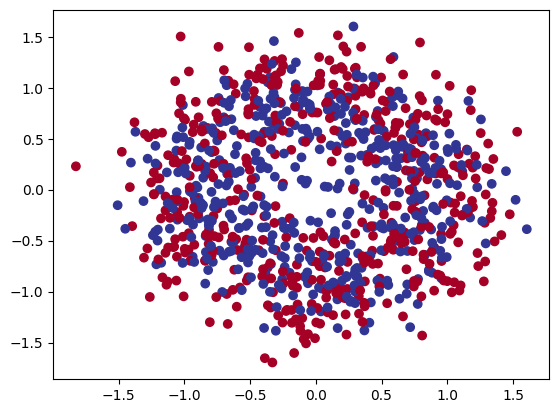

In [40]:
#visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu)

In [41]:
# Checking input and poutput shapes
X.shape, y.shape

((1000, 2), (1000,))

In [42]:
X_sample = X[0]
y_sample = y[0]

X_sample, y_sample, X_sample.shape, y_sample.shape

(array([0.59171471, 0.43674853]), np.int64(1), (2,), ())

# Trun the data into Tensor

In [43]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [44]:
X[:5], y[:5]

(tensor([[ 0.5917,  0.4367],
         [-0.4575,  0.3616],
         [-1.0107,  0.8304],
         [-0.8717,  0.4141],
         [ 0.4880, -0.8726]]),
 tensor([1., 1., 1., 1., 0.]))

In [45]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [46]:
# Split data into  train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)


In [47]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# Building the Model

In [48]:
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=1)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))


model_0 = CircleModel().to(device)
model_0

CircleModel(
  (layer_1): Linear(in_features=2, out_features=1, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [49]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [50]:
# Make prediction
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.5188,  0.6146],
                      [ 0.1323,  0.5224],
                      [ 0.0958,  0.3410],
                      [-0.0998,  0.5451],
                      [ 0.1045, -0.3301]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.1802, -0.3258, -0.0829, -0.2872,  0.4691], device='cuda:0')),
             ('1.weight',
              tensor([[-0.3530, -0.2062, -0.1263, -0.2689,  0.0422]], device='cuda:0')),
             ('1.bias', tensor([-0.4417], device='cuda:0'))])

In [51]:
untrained_preds = model_0(X_test.to(device))
len(untrained_preds), untrained_preds.shape, X_test.shape, y_test.shape

(200, torch.Size([200, 1]), torch.Size([200, 2]), torch.Size([200]))

In [52]:
untrained_preds[:10], y_test[:10]

(tensor([[-0.6629],
         [-0.5477],
         [-0.3274],
         [-0.9273],
         [ 0.4160],
         [ 0.3975],
         [-0.3377],
         [-0.2362],
         [ 0.0917],
         [-0.7351]], device='cuda:0', grad_fn=<SliceBackward0>),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

# Choosing loss functiona nd optimizer
- For regress MAE OR MSE
- For classification BinaryCrossEntropy

- Common optimizer is adam and sgd for regression and classification

In [53]:
## Setup loss function and optimizer
# loss_fn - nn.BCELoss requires inputs to hve gone through the sigmoid activation fuction prior to input to BCELOSS
loss_fn = nn.BCEWithLogitsLoss() ## sigmoid activation function buil-in
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [54]:
# Calculate accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc


# Now train the model

In [55]:
model_0.eval()
with torch.inference_mode():
      y_logits = model_0(X_test.to(device))[:5]


y_logits

tensor([[-0.6629],
        [-0.5477],
        [-0.3274],
        [-0.9273],
        [ 0.4160]], device='cuda:0')

In [56]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [57]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3401],
        [0.3664],
        [0.4189],
        [0.2835],
        [0.6025]], device='cuda:0')

In [58]:
y_preds = torch.round(y_pred_probs)

# Building and testing loop

In [59]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epoch in range(epochs):

  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # loss = loss_fn(torch.sigmoid(y_logits), y_train)  if nn.BCELoss expect predictionn probability as input

  loss = loss_fn(y_logits, y_train) #nn.BCEWithLogitsLoss expects raw logits as input

  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  #Optimimizer zero grad
  optimizer.zero_grad()

  #Loss backward
  loss.backward()

  # Optimizer step
  optimizer.step()

  ## Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc{acc:.2f} | Test loss: {test_loss:.5f}%, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.72804, Acc45.38 | Test loss: 0.71470%, Test acc: 52.00%
Epoch: 10 | Loss: 0.71728, Acc45.00 | Test loss: 0.70522%, Test acc: 50.50%
Epoch: 20 | Loss: 0.71062, Acc46.12 | Test loss: 0.69980%, Test acc: 50.50%
Epoch: 30 | Loss: 0.70622, Acc47.00 | Test loss: 0.69655%, Test acc: 52.00%
Epoch: 40 | Loss: 0.70315, Acc46.88 | Test loss: 0.69453%, Test acc: 51.50%
Epoch: 50 | Loss: 0.70093, Acc46.50 | Test loss: 0.69327%, Test acc: 50.50%
Epoch: 60 | Loss: 0.69928, Acc46.00 | Test loss: 0.69246%, Test acc: 50.00%
Epoch: 70 | Loss: 0.69802, Acc45.75 | Test loss: 0.69196%, Test acc: 50.50%
Epoch: 80 | Loss: 0.69705, Acc45.88 | Test loss: 0.69166%, Test acc: 51.00%
Epoch: 90 | Loss: 0.69629, Acc46.38 | Test loss: 0.69150%, Test acc: 51.00%
Epoch: 100 | Loss: 0.69569, Acc46.75 | Test loss: 0.69144%, Test acc: 52.50%
Epoch: 110 | Loss: 0.69521, Acc47.12 | Test loss: 0.69144%, Test acc: 52.50%
Epoch: 120 | Loss: 0.69483, Acc46.88 | Test loss: 0.69148%, Test acc: 51.50%
Epoch: 130

In [60]:
import requests

from pathlib import Path

if Path("helper_fucmtios.py").is_file():
  print("helper_function.py is already exists, skipping download")
else:
  print("Download helper_function.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")

  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

Download helper_function.py


In [61]:
from helper_functions import plot_predictions, plot_decision_boundary

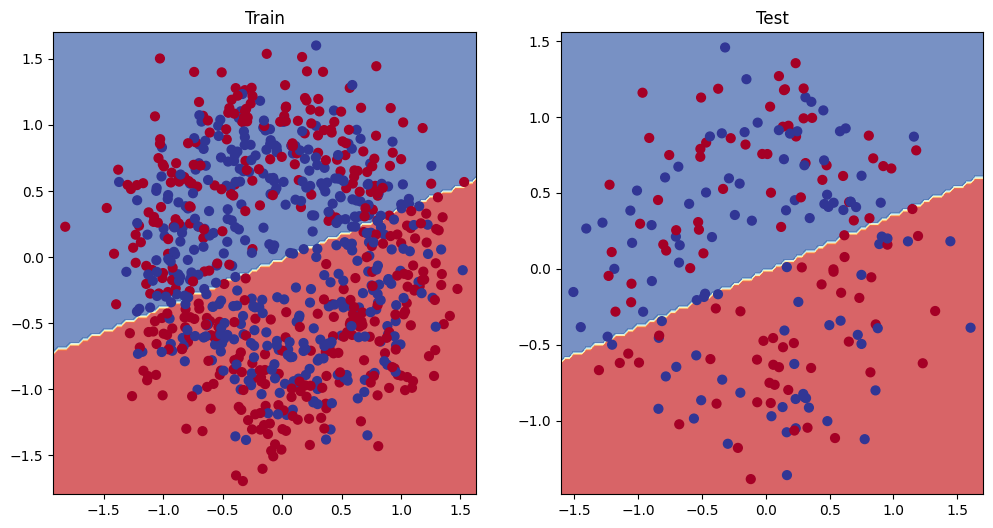

In [63]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

# Improving Model

- Add More Layers
- Add more hidden units
- Fit for longer
- Changing the activation function

- Changing the learning rate
- Changing the loss function
- Changing the optimizer


In [68]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer3(self.layer2(self.layer_1(x)))


model_1 = CircleModelV1().to(device)

In [69]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01)


In [71]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)

X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
   model_1.train()

   y_logits = model_1(X_train).squeeze()
   y_pred = torch.round(torch.sigmoid(y_logits))

   loss = loss_fn(y_logits, y_train)

   acc = accuracy_fn(y_true=y_train,
                     y_pred=y_pred)

   optimizer.zero_grad()

   loss.backward()

   optimizer.step()

   model_1.eval()

   with torch.inference_mode():

    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc{acc:.2f} | Test loss: {test_loss:.5f}%, Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.69370, Acc51.12 | Test loss: 0.69300%, Test acc: 48.50%
Epoch: 10 | Loss: 0.69367, Acc51.00 | Test loss: 0.69300%, Test acc: 48.50%
Epoch: 20 | Loss: 0.69364, Acc50.50 | Test loss: 0.69300%, Test acc: 49.00%
Epoch: 30 | Loss: 0.69362, Acc50.50 | Test loss: 0.69301%, Test acc: 47.50%
Epoch: 40 | Loss: 0.69359, Acc50.88 | Test loss: 0.69301%, Test acc: 46.50%
Epoch: 50 | Loss: 0.69357, Acc50.62 | Test loss: 0.69301%, Test acc: 46.50%
Epoch: 60 | Loss: 0.69355, Acc50.50 | Test loss: 0.69302%, Test acc: 46.50%
Epoch: 70 | Loss: 0.69353, Acc50.25 | Test loss: 0.69302%, Test acc: 46.50%
Epoch: 80 | Loss: 0.69351, Acc50.00 | Test loss: 0.69303%, Test acc: 46.50%
Epoch: 90 | Loss: 0.69349, Acc50.12 | Test loss: 0.69304%, Test acc: 46.50%
Epoch: 100 | Loss: 0.69348, Acc50.00 | Test loss: 0.69304%, Test acc: 47.50%
Epoch: 110 | Loss: 0.69346, Acc49.88 | Test loss: 0.69305%, Test acc: 47.00%
Epoch: 120 | Loss: 0.69344, Acc49.50 | Test loss: 0.69306%, Test acc: 48.00%
Epoch: 130

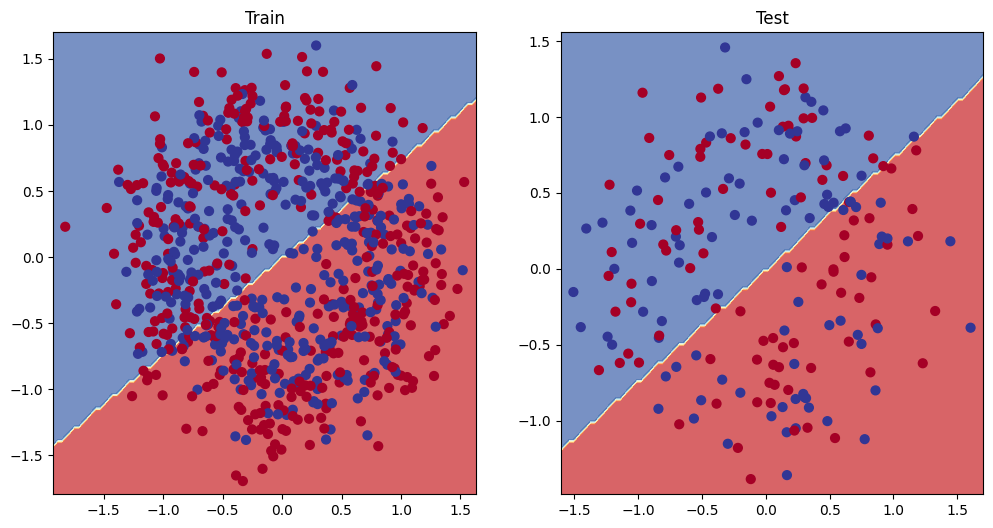

In [72]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)